In [3]:
import pandas as pd
import numpy as np
# ============================================
# CONFIGURACIÓN
# ============================================
EXPORTAR_LIMPIO = True  # Cambia a False si NO quieres exportar el CSV
TAMANO_MUESTRA = 100000  # Cantidad de canciones para la muestra final
# ============================================
# CARGAR DATOS
# ============================================
print("📀 Cargando dataset...")
df = pd.read_csv('universal_top_spotify_songs.csv')
print(f"✅ Dataset cargado: {len(df):,} canciones")
# ============================================
# LAS 11 FEATURES QUE USAREMOS (según tu tabla)
# ============================================
features = [
    'danceability',    # float (0-1) - Qué tan bailable es
    'energy',          # float (0-1) - Intensidad/actividad
    'valence',         # float (0-1) - Positividad/alegría
    'acousticness',    # float (0-1) - Acústica vs electrónica
    'instrumentalness', # float (0-1) - Si no tiene voz
    'liveness',        # float (0-1) - Si tiene audiencia en vivo
    'speechiness',     # float (0-1) - Cantidad de palabras habladas
    'tempo',           # float (BPM) - Velocidad de la canción
    'loudness',        # float (dB) - Volumen (negativo a positivo)
    'duration_ms',     # int (ms) - Duración
    'mode'             # int (0 o 1) - Mayor o menor
]
# Verificar que todas las columnas existen en el dataset
columnas_faltantes = [col for col in features if col not in df.columns]
if columnas_faltantes:
    print(f"⚠️ Atención: Estas columnas NO existen en el dataset: {columnas_faltantes}")
else:
    print(f"✅ Las 11 features existen en el dataset")
# ============================================
# 1. DIAGNÓSTICO COMPLETO
# ============================================
print("\n" + "="*60)
print("🔍 DIAGNÓSTICO COMPLETO DEL DATASET")
print("="*60)
# 1.1 Valores nulos
print("\n📌 1. VALORES NULOS:")
print("-"*40)
nulos = df[features].isnull().sum()
if nulos.sum() == 0:
    print("✅ No hay valores nulos en ninguna feature")
else:
    print(nulos[nulos > 0])
# 1.2 Valores imposibles
print("\n📌 2. VALORES IMPOSIBLES:")
print("-"*40)
tempo_cero = df[df['tempo'] == 0]
print(f"⚠️ tempo = 0: {len(tempo_cero)} canciones")
# Verificar mode (debe ser 0 o 1)
mode_fuera = df[(df['mode'] != 0) & (df['mode'] != 1)]
if len(mode_fuera) > 0:
    print(f"⚠️ mode fuera de rango (0 o 1): {len(mode_fuera)} canciones")
# Verificar duration_ms > 0
duration_cero = df[df['duration_ms'] <= 0]
if len(duration_cero) > 0:
    print(f"⚠️ duration_ms <= 0: {len(duration_cero)} canciones")
# 1.3 Duplicados exactos
print("\n📌 3. DUPLICADOS EXACTOS (misma fila en todas las columnas):")
print("-"*40)
duplicados = df.duplicated().sum()
print(f"⚠️ Filas duplicadas: {duplicados}")
# 1.4 Tipos de datos
print("\n📌 4. TIPOS DE DATOS:")
print("-"*40)
for col in features:
    print(f"   {col}: {df[col].dtype}")
# ============================================
# 2. LIMPIEZA
# ============================================
print("\n" + "="*60)
print("🧹 APLICANDO LIMPIEZA")
print("="*60)
df_limpio = df.copy()
# Eliminar tempo = 0
antes = len(df_limpio)
df_limpio = df_limpio[df_limpio['tempo'] > 0]
print(f"✅ Eliminadas {antes - len(df_limpio)} canciones con tempo = 0")
# Eliminar mode que no sea 0 o 1 (si existe)
antes = len(df_limpio)
df_limpio = df_limpio[(df_limpio['mode'] == 0) | (df_limpio['mode'] == 1)]
print(f"✅ Eliminadas {antes - len(df_limpio)} canciones con mode inválido")
# Eliminar duration_ms <= 0
antes = len(df_limpio)
df_limpio = df_limpio[df_limpio['duration_ms'] > 0]
print(f"✅ Eliminadas {antes - len(df_limpio)} canciones con duration_ms <= 0")
# Eliminar duplicados exactos
antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates()
print(f"✅ Eliminadas {antes - len(df_limpio)} filas duplicadas")
# Eliminar nulos en las features
antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=features)
print(f"✅ Eliminadas {antes - len(df_limpio)} canciones con valores nulos")
print(f"\n📊 RESULTADO FINAL: {len(df_limpio):,} canciones listas para clustering")
# ============================================
# 3. EXPORTAR CSV LIMPIO (OPCIONAL)
# ============================================
if EXPORTAR_LIMPIO:
    print("\n" + "="*60)
    print("💾 EXPORTANDO DATASET LIMPIO")
    print("="*60)

    # Exportar completo
    df_limpio.to_csv('universal_top_spotify_songs_clean.csv', index=False)
    print("✅ Exportado: universal_top_spotify_songs_clean.csv")

    # Exportar solo las 11 features
    df_features = df_limpio[features]
    df_features.to_csv('spotify_features_only.csv', index=False)
    print("✅ Exportado: spotify_features_only.csv (solo las 11 features)")
else:
    print("\n⏭️ Exportación desactivada (EXPORTAR_LIMPIO = False)")
# ============================================
# 4. MUESTRA PARA CLUSTERING
# ============================================
print("\n" + "="*60)
print("🎯 MUESTRA PARA CLUSTERING")
print("="*60)
# Tomar muestra aleatoria
df_muestra = df_limpio.sample(n=min(TAMANO_MUESTRA, len(df_limpio)), random_state=42)
# Escalar los datos (necesario para clustering)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_muestra[features])
print(f"✅ Muestra tomada: {len(df_muestra):,} canciones")
print(f"✅ Features escaladas: {X_scaled.shape[1]} variables")
print(f"✅ Escalador guardado (usar mismo para nuevos datos)")
# Exportar muestra
if EXPORTAR_LIMPIO:
    # Muestra original (sin escalar)
    df_muestra.to_csv('spotify_muestra_100k.csv', index=False)
    print("✅ Exportado: spotify_muestra_100k.csv (datos sin escalar)")

    # Muestra escalada
    df_muestra_scaled = pd.DataFrame(X_scaled, columns=features)
    df_muestra_scaled.to_csv('spotify_muestra_100k_scaled.csv', index=False)
    print("✅ Exportado: spotify_muestra_100k_scaled.csv (datos escalados, listos para clustering)")
# ============================================
# 5. RESUMEN FINAL
# ============================================
print("\n" + "="*60)
print("📋 RESUMEN FINAL")
print("="*60)
print(f"""
─────────────────────────────────────────────────────────────
\tDATASET ORIGINAL:\t{2_110_316:>12,} canciones
\tDATASET LIMPIO:\t{len(df_limpio):>12,} canciones
\tMUESTRA PARA ML:\t{len(df_muestra):>12,} canciones
\tFEATURES USADAS:\t{len(features):>12} variables
─────────────────────────────────────────────────────────────
\tLISTA DE FEATURES:
\t1. danceability     7. liveness
\t2. energy           8. speechiness
\t3. valence          9. tempo
\t4. acousticness     10. loudness
\t5. instrumentalness 11. duration_ms
\t6. mode
─────────────────────────────────────────────────────────────
\t✅ Dataset listo para aplicar los 3 algoritmos:
\t\t- K-Means
\t\t- DBSCAN
\t\t- Agglomerative Clustering
─────────────────────────────────────────────────────────────
""")
# ============================================
# 6. ESTADÍSTICAS DE LA MUESTRA
# ============================================
print("\n📊 ESTADÍSTICAS DE LA MUESTRA (datos sin escalar):")
print("-"*40)
print(df_muestra[features].describe().round(3))
# ============================================
# 7. VERIFICACIÓN FINAL DE RANGOS
# ============================================
print("\n📌 VERIFICACIÓN DE RANGOS ESPERADOS:")
print("-"*40)
rangos = {
    'danceability': (0, 1),
    'energy': (0, 1),
    'valence': (0, 1),
    'acousticness': (0, 1),
    'instrumentalness': (0, 1),
    'liveness': (0, 1),
    'speechiness': (0, 1),
    'tempo': (0, 300),
    'loudness': (-60, 10),
    'duration_ms': (1000, 600000),  # 1 segundo a 10 minutos
    'mode': (0, 1)
}
for feature, (min_esp, max_esp) in rangos.items():
    valores = df_muestra[feature]
    fuera = valores[(valores < min_esp) | (valores > max_esp)]
    if len(fuera) > 0:
        print(f"⚠️ {feature}: {len(fuera)} valores fuera de rango [{min_esp}, {max_esp}]")
    else:
        print(f"✅ {feature}: todos en rango [{min_esp}, {max_esp}]")


📀 Cargando dataset...
✅ Dataset cargado: 2,110,316 canciones
✅ Las 11 features existen en el dataset

🔍 DIAGNÓSTICO COMPLETO DEL DATASET

📌 1. VALORES NULOS:
----------------------------------------
✅ No hay valores nulos en ninguna feature

📌 2. VALORES IMPOSIBLES:
----------------------------------------
⚠️ tempo = 0: 1 canciones
⚠️ duration_ms <= 0: 29 canciones

📌 3. DUPLICADOS EXACTOS (misma fila en todas las columnas):
----------------------------------------
⚠️ Filas duplicadas: 0

📌 4. TIPOS DE DATOS:
----------------------------------------
   danceability: float64
   energy: float64
   valence: float64
   acousticness: float64
   instrumentalness: float64
   liveness: float64
   speechiness: float64
   tempo: float64
   loudness: float64
   duration_ms: int64
   mode: int64

🧹 APLICANDO LIMPIEZA
✅ Eliminadas 1 canciones con tempo = 0
✅ Eliminadas 0 canciones con mode inválido
✅ Eliminadas 29 canciones con duration_ms <= 0
✅ Eliminadas 0 filas duplicadas
✅ Eliminadas 0 cancion

In [19]:
import pandas as pd
import numpy as np

# 1. CARGA DE DATOS
# Se carga el dataset ya limpio
df = pd.read_csv('spotify_features_only.csv')
print(f"Total de canciones: {len(df):,}")

# 2. ELIMINACIÓN DE OUTLIERS
# Se elimina canciones mayores de 10 minutos para que estas no ocacione outliers
# DBSCAN es sensible a la densidad → valores extremos afectan clusters
df = df[df['duration_ms'] <= 600000]
print(f"Después de filtrar: {len(df):,}")

Total de canciones: 2,110,286
Después de filtrar: 2,109,262


Se trabaja con un dataset de más de 2.1 millones de canciones, lo que permite obtener resultados representativos del comportamiento global de la música en Spotify.

In [20]:
# 3. MUESTREO
# Se utiliza una muestra de 100,000 canciones
# Se reduce debido a que en DBSCAN tiene alto costo computacional (memoria y tiempo)
sample_size = 100000
df_sample = df.sample(n=sample_size, random_state=42)

print(f"Muestra tomada: {len(df_sample):,}")

Muestra tomada: 100,000


Debido al alto costo computacional de DBSCAN, se utiliza una muestra de 100,000 canciones, suficiente para mantener la representatividad sin comprometer el rendimiento.

In [21]:
# 4. SELECCIÓN DE FEATURES
features = [
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'instrumentalness',
    'liveness',
    'speechiness',
    'tempo',
    'loudness',
    'duration_ms',
    'mode'
]

In [22]:
# 5. ESCALADO DE DATOS
# Las variables tienen distintas escalas:
# - tempo ~ 120
# - loudness ~ -6
# - danceability ~ 0.6
#
# Sin escalado:
# → DBSCAN daría más importancia a tempo
#
# Con StandardScaler:
# → todas las variables tienen media = 0 y desviación estándar = 1
#
# Fórmula utilizada:
# z = (x - media) / desviación estándar

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

Se aplicó StandardScaler para normalizar las variables, el escalado de datos es fundamental para evitar que variables con mayor magnitud dominen el cálculo de distancias, asegurando que todas las características contribuyan de manera equitativa lo cual es fundamental para los algoritmos basados en densidad como lo es DBSCAN.
Al utilizar el StandardScaler se usa la siguiente formula:

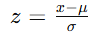

In [23]:
# 6. REDUCCIÓN DE DIMENSIONES (PCA)
# Reduccion de dimensiones
# Es la combinacion de 11 a 3 componentes principales
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Se imprime cuánta información se conserva
print("Varianza explicada:", pca.explained_variance_ratio_)
print("Total:", sum(pca.explained_variance_ratio_))

Varianza explicada: [0.25156594 0.11850518 0.1068412 ]
Total: 0.47691231530440314


Se aplicó PCA para reducir la dimensionalidad de 11 a 3 variables, conservando aproximadamente el 47% de la información, lo cual permite mejorar la eficiencia del algoritmo sin perder la estructura principal de los datos.

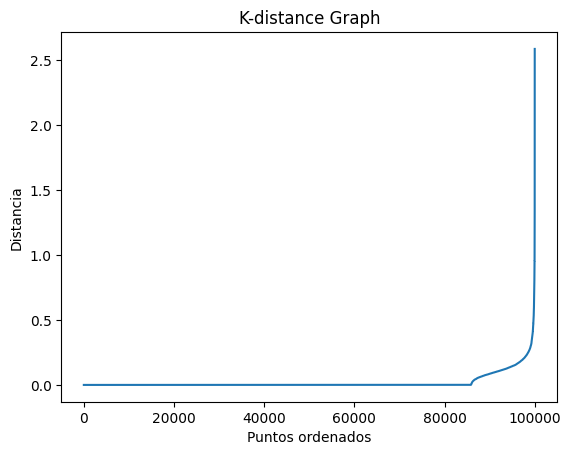

In [24]:
# 7. K-DISTANCE GRAPH (ELECCIÓN DE EPS)
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Se busca los 5 vecinos mas cercanos
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)

# Distancia al 5to vecino
distances, _ = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, 4])

# Gráfico
plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia")
plt.show()

In [25]:
# 8. OPTIMIZACIÓN DE MEMORIA
# Convertir a float32 para reducir uso de RAM
X_pca = X_pca.astype('float32')

In [26]:
import numpy as np
from sklearn.cluster import DBSCAN

# 9. Uso del algoritmo DBSCAN

dbscan = DBSCAN(
    eps=1.1,           # radio de vecindad
    min_samples=5,     # mínimo de puntos para formar cluster
    algorithm='ball_tree',
    n_jobs=-1
)

clusters = dbscan.fit_predict(X_pca)

# 10. RESULTADOS DEL MODELO
# Se obtiene la cantidad de clusters
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
noise = list(clusters).count(-1)

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos ruido: {noise}")

Clusters encontrados: 7
Puntos ruido: 11


El algoritmo DBSCAN permite identificar clusters basados en densidad, detectando tanto grupos naturales de canciones como canciones atípicas (ruido), sin necesidad de definir previamente el número de clusters.

In [27]:
# 11. ANÁLISIS DE CLUSTERS
# Se agrega el cluster al dataset
df_sample['cluster'] = clusters

In [28]:
# Promedio de los features por cluster
# Segun el resultado obtenido se dira el tipo de cancion
cluster_summary = df_sample.groupby('cluster').mean()
print(cluster_summary)

         danceability    energy   valence  acousticness  instrumentalness  \
cluster                                                                     
-1           0.339882  0.511398  0.262527      0.506262          0.403830   
 0           0.678177  0.651391  0.549022      0.274096          0.019981   
 1           0.144908  0.393261  0.061835      0.582993          0.732268   
 2           0.168000  0.003320  0.219000      0.192000          0.790000   
 3           0.093900  0.001740  0.067900      0.247000          0.000195   
 4           0.458000  0.297000  0.357000      0.866000          0.329000   
 5           0.418000  0.106000  0.800000      0.994000          0.029200   
 6           0.363286  0.770857  0.384143      0.642869          0.087000   

         liveness  speechiness       tempo   loudness    duration_ms      mode  
cluster                                                                         
-1       0.490091     0.196055  150.263727 -13.376364  229506.72727

**CLUSTER 0:** Este cluster agrupa la gran cantidad de canciones. Se caracteriza por una alta bailabilidad, energía moderada-alta y un nivel medio de positividad. Representa el perfil típico de las canciones populares en plataformas como Spotify.

**CLUSTER 1:** Canciones con muy baja bailabilidad, baja positividad y alta instrumentalidad. Predomina un estilo musical emocional, introspectivo y sin presencia vocal significativa.

**CLUSTER 2:** Este grupo contiene canciones con niveles extremadamente bajos de energía y volumen, muchas de ellas instrumentales. Se asocia con música ambiental o de fondo.

**CLUSTER 3:** Canciones caracterizadas por tempos bajos, energía mínima y baja positividad. Representan estilos lentos y tranquilos, típicos de baladas.

**CLUSTER 4:** Destaca por un alto nivel de speechiness (voz hablada) y alta acústica. Puede asociarse a estilos como rap suave.

**CLUSTER 5:** Canciones con alta positividad pero baja energía. Representan música alegre pero tranquila, ideal para ambientes relajados.

**CLUSTER 6:** Este grupo presenta alta energía, alto tempo y valores elevados de liveness, indicando presentaciones en vivo o grabaciones con audiencia.

**CLUSTER -1 (ruido):** Este grupo contiene canciones que no pertenecen a ningún cluster claro. Se consideran outliers con características poco comunes o combinaciones inusuales.

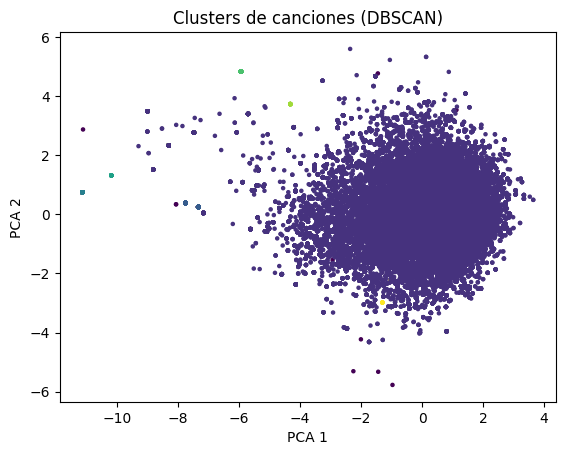

In [29]:
import matplotlib.pyplot as plt

# 12. VISUALIZACIÓN

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=5)
plt.title("Clusters de canciones (DBSCAN)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

En este grafico se puede observar los diferentes clusters existentes con DBSCAN, tambien se puede ver que el cluster mas dominante es el cluster 0, que los demas clusters son muchos mas pequeños, se puede observar una densidad alta siendo el cluster principal y puntos dispersos los cuales algunos son los otros clusters pequeños.

In [30]:
# Cantidad de canciones segun el cluster
df_sample['cluster'].value_counts()

,count
cluster,
0,99414
1,295
2,152
4,90
3,16
5,15
-1,11
6,7


Siendo el cluster mas dominante del cluster 0 (canciones mas populares) y el menos del cluster 6 (canciones en vivo).

<Axes: xlabel='cluster'>

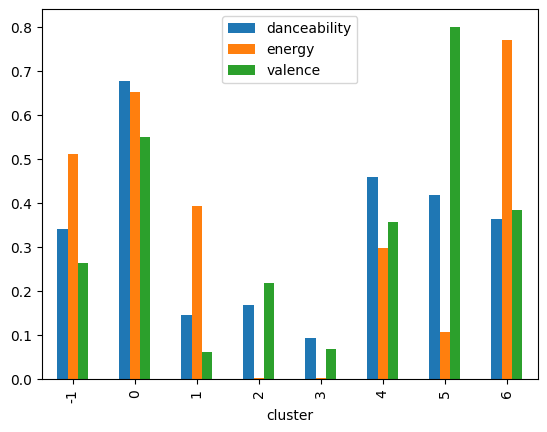

In [35]:
# Grafico de barras de los clusters
cluster_summary[['danceability','energy','valence']].plot(kind='bar')

En este grafico se puede observar los diferentes clusters, donde se muestra la dancebility, energy y valance.

**Respuestas segun el algosritmo DBSCAN**
**¿Cuántos tipos de canciones existen?**

Segun el algoritmo DBSCAN se identificaron 7 grupos, mostrando que existe un tipo de musica dominante.

**¿Podemos ponerles nombres bonitos a los clusters?**

Hits comerciales, Instrumental triste, Ambiental, Balada lenta, rap, musica feliz tranquila, musicas en vivo, canciones extrañas.

**¿Qué receta funciona? Si una discográfica quiere lanzar un nuevo éxito, ¿qué valores de danceability, energy y valence debería buscar?**

Canciones bailables, energéticas y moderadamente felices tienen mayor probabilidad de éxito.

**MÉTRICAS**

In [31]:
from sklearn.metrics import silhouette_score

# SILHOUETTE SCORE
# Mide: qué tan bien está cada punto dentro de su cluster y que tan separado está de otros clusters
# > 0.7	Excelente
# 0.5 – 0.7	Bueno
# 0.25 – 0.5	Aceptable
# < 0.25	Malo
score = silhouette_score(X_pca, clusters)
print(score)

0.44501615


El resultado muestra que los clusters se encuentran bien formados pero existe cierta superposición entre ellos.

In [32]:
from sklearn.metrics import davies_bouldin_score

# DAVIES-BOULDIN INDEX
# Mide: Qué tan compactos y separados están los clusters
# < 1	Muy bueno
# 1 – 2	Aceptable
# > 2	Malo

dbi = davies_bouldin_score(X_pca, clusters)
print(dbi)

1.1173037344613894


Los clusters tienen una separación aceptable y no están demasiado mezclados.

In [33]:
from sklearn.metrics import calinski_harabasz_score

# CALINSKI-HARABASZ INDEX
# Mide: separación entre clusters y cohesión interna
# Más alto = mejor

ch = calinski_harabasz_score(X_pca, clusters)
print(ch)

1507.5549


Existe una buena separación global entre los clusters encontrados.

El modelo DBSCAN presenta un rendimiento adecuado para la segmentación de canciones, con un Silhouette Score de 0.445 que indica una estructura de clusters aceptable. El índice de Davies-Bouldin (1.117) sugiere que los clusters mantienen una separación razonable, mientras que el índice de Calinski-Harabasz (1507.55) confirma una buena separación global entre grupos. En conjunto, estos resultados validan que el modelo logra identificar patrones significativos dentro de los datos musicales.